In [20]:
#importing dataset named kc_house_data

In [21]:
import pandas as pd
houses = pd.read_csv("kc_house_data.csv")

In [22]:
#Understanding the dataset

In [23]:
houses.head()
houses.describe()
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [24]:
#checking for null values

In [25]:
houses.isnull().sum() #checks all the columns and sums all the null values in the column

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [26]:
#visulize the data

In [27]:
houses.dtypes
houses_nodate = houses.drop(columns = 'date')

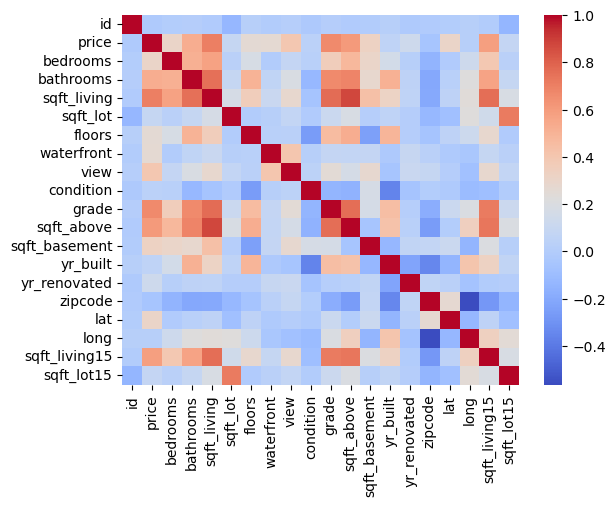

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(houses_nodate.corr(),cmap = 'coolwarm')
plt.show()

In [29]:
#feature selection

In [30]:
selected_features = ['sqft_living','bedrooms','bathrooms','view','grade',
                     'yr_built','sqft_living15','floors','waterfront','condition','lat']
X = houses[selected_features]
Y= houses['price']

In [31]:
#build the model
#Simple linear Regression

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
print("Intercept:", model.intercept_)
print("Coefficient for power_1:", model.coef_[0])

Intercept: -21872248.878052182
Coefficient for power_1: 160.8102758565511


In [42]:
import numpy as np
from sklearn.metrics import root_mean_squared_error, r2_score

predictions = model.predict(X_test)
print("R2 Score:", r2_score(y_test, predictions))
print("RMSE:", root_mean_squared_error(y_test, predictions))

R2 Score: 0.6761035504336752
RMSE: 212033.77031852517
